In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

### Normal-Gaussian Distribution

1. Famous bell shaped curve where data is equally distributed on both right and left side of mean value with equal Standard Deviation
2. It is symmetric around the mean.
3. Standard Distribution - Spread or dispersion
4. Here we find Probability Density Function (PDF)

1. pdf shows Probability Density Functions
2. Cummulative Density Function= give probability for greater/smaller than prob value

Que1. Person with height data with mean=170 and SD=10, what is probability that person is going to be more than 180

### Python Template to find Normal Prob Distribution 

In [20]:
def normal_distribution_solver(mean, std_dev, value1=None, value2= None, n=None, plot=True):
    """
    Solves probability problems for Normal Distribution.

    Parameters:
    - mean (float): mean of distribution
    - std_dev (float): standard deviation
    - value1 (float): lower bound (or single value if only one side)
    - value2 (float): upper bound (optional)
    - n (int): total population size (optional, for expected count)
    - plot (bool): whether to show the curve plot

    Returns:
    - probability (float)
    - expected_count (float if n provided else None)
    """
    # case 1 : Single Size Probability - calculating prob for upper bound
    # P(X > value1)
    if value2 is None: 
        z_prob= 1 - norm.cdf(value1, loc=mean, scale=std_dev)
        case = f"P(x > value1 : {value1})"
        x_fill= np.linspace(value1, mean + 4*std_dev, 200) # create smaller range from value1 -> right tail

    elif value1 is None: # Case: P(X < value2) - lower bound
        z_prob= norm.cdf(value2, loc= mean, scale= std_dev)
        case = f"P(x < value 2) : {value2}"
        x_fill= np.linspace(mean- 4 * std_dev, value2, 200) # create smaller range from value2 -> left tail 
    
    else : # Case: Between value1 and value2
        z_prob= norm.cdf(value2, loc=mean, scale=std_dev) - norm.cdf(value1, loc= mean, scale= std_dev)
        case = f"P({value1} <= X <= {value2})"
        x_fill= np.linspace(value1, value2, 200) # create smaller range from value1 to value2
    
    # Expected count if n given
    expected_count= z_prob * n if n else None

    "To plot a curve"
    if plot:
        #We generate a range of x-values.covers ~99.99% of data in Normal distribution).500 = number of equally spaced points → makes curve smooth.
        x= np.linspace(mean-4*std_dev , mean +4 * std_dev, 500) #x-axis values
        y= norm.pdf(x, mean, std_dev) #tells how dense probability is at each x. For each x in the above range, we compute its height on the bell curve.
        plt.figure(figsize=(8,5)) #
        plt.plot(x, y, 'b', label="Normal Distribution") #Draws the bell curve (x vs y). 'b-' means: blue color + solid line.


        """To highlighting the probability"""
        # as we have create x_fill smaller range from value2 -> right tail(above 75) left tail for value1(below 75)
        # now calculate prob density function (pdf) for this x_fill so that we can fill color in this area
        y_fill= norm.pdf(x_fill, loc=mean, scale= std_dev)
        # and use fill_between() to fill area between y_fill and x_fill
        plt.fill_between(x_fill,0, y_fill, alpha=0.5, color='g')
        plt.axvline(mean, color='k',linestyle='--', label=f"mean = {mean}" ) # draw the mean line 
        plt.title(f"{case}\nProbability : {z_prob:.4f}")
        plt.xlabel(f"X values")
        plt.ylabel(f"Density")
        plt.legend()
        plt.show()

    return {
        "case" : case,
        "Probability" : round(z_prob, 4),
        "Expected Count" : round(expected_count, 2) if expected_count else None 
    }


### Que1. Probability Density Function - below

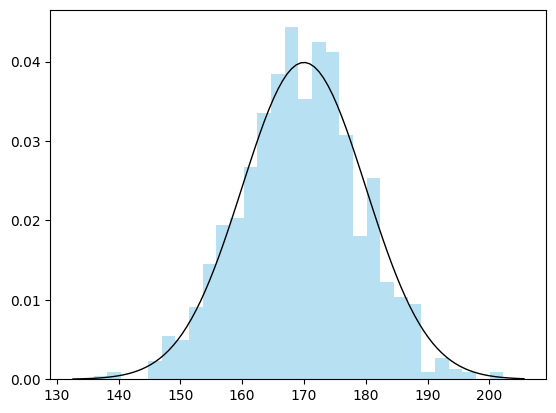

In [29]:
# generate random data set
mu, sigma= 170, 10 #sigma=SD, mu=mean
heights= np.random.normal(mu, sigma, 1000)

plt.hist(heights,bins=30, density=True, alpha= 0.6, color='skyblue')
xmin, xmax=plt.xlim()
x= np.linspace(xmin, xmax, 100)
pdf= norm.pdf(x, mu, sigma)
pdf
plt.plot(x, pdf, 'k', linewidth=1)


### Cummulative Density Function - to find prob

In [16]:
x= 180
cdf= 1- norm.cdf(x, mu, sigma)
cdf 
# 0.1586 - 15.8% probability that person having 180 height

np.float64(0.15865525393145707)

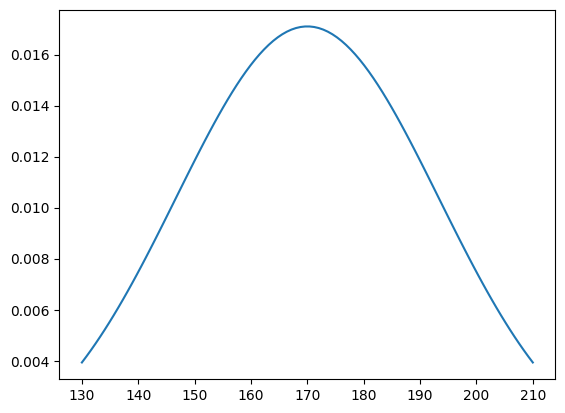

In [17]:
x=np.linspace(130,210,100)
mu=x.mean()
std=x.std()

pdf = norm.pdf(x,mu,std)
cdf= norm.cdf(x, mu, std)

plt.plot(x, pdf)

Que2. Q1: Exam Scores

A class of 200 students has marks distributed normally with mean = 65 and σ = 10.
1. 👉 Find the probability that a randomly selected student scores above 75.
2. 👉 What % of students score between 55 and 75?

### Universal Step-by-Step Approach for Normal Distribution Problems

1. Understand the Question
    Identify:
    1. Mean (μ)
    2. Standard deviation (σ)
    3. What probability range is being asked (above, below, between)?
    4. Sample size (if asked about number of people/things).

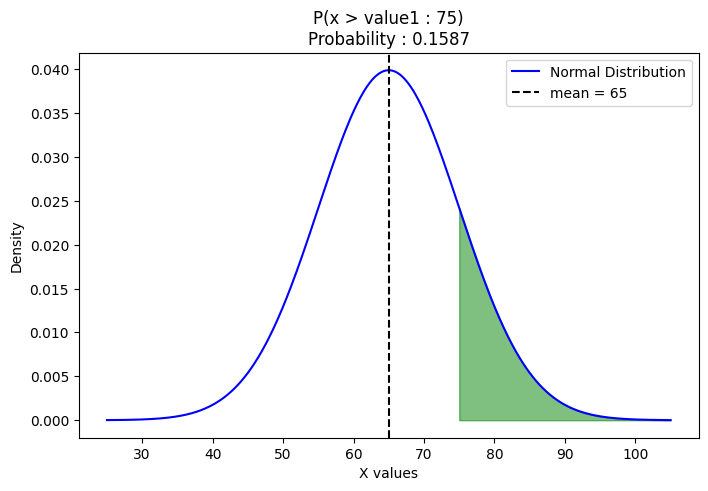

{'case': 'P(x > value1 : 75)',
 'Probability': np.float64(0.1587),
 'Expected Count': np.float64(31.73)}

In [39]:
#👉 Find the probability that a randomly selected student scores above 75.
mu= 65
sigma= 10
# prob range being ask
x1= 75
# x2= 55 <= x <= 75
# sample size 200 
result=normal_distribution_solver(mu, sigma, x1, n=200)
result

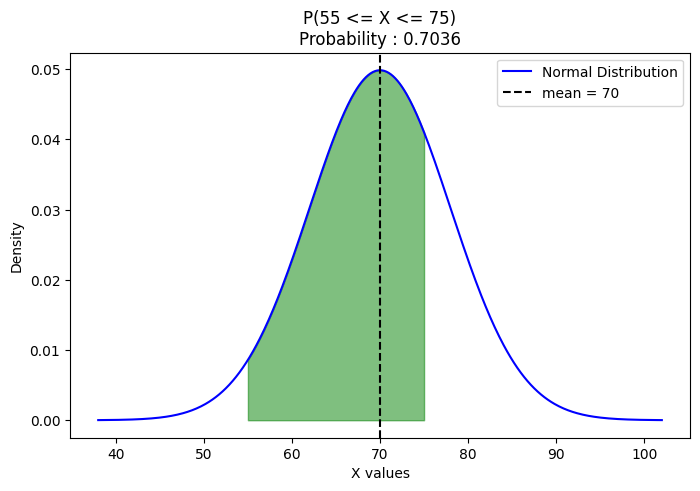

{'case': 'P(55 <= X <= 75)',
 'Probability': np.float64(0.7036),
 'Expected Count': np.float64(140.72)}

In [45]:
#👉 What % of students score between 55 and 75?

result2= normal_distribution_solver(mu, sigma,value1=55, value2=75, n=200)
result2

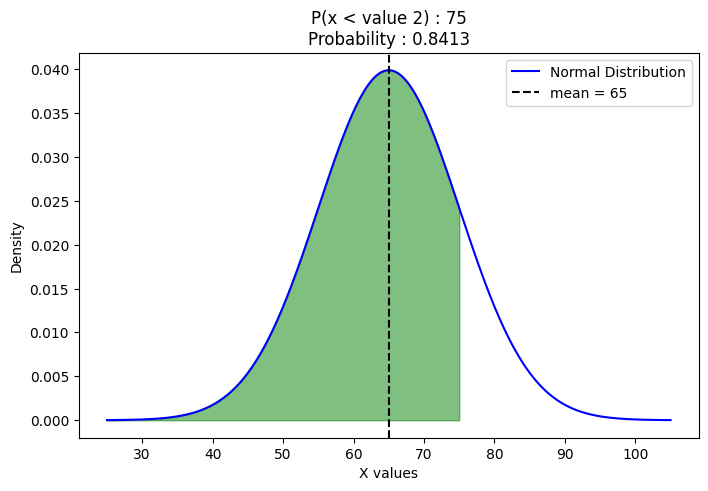

In [42]:
# 👉 Find the probability that a randomly selected student scores till 75.
result= normal_distribution_solver(mu,sigma, value1=None,value2=75, n=200)

In [23]:
# rewriting our normal prob functions

def normal_prob_analyser(mean, std_dev, value1=None, value2=None, n=None, plot=True):
    
    if value2 is None: # if want to calculate higher prob than particular value
        z_prob= 1 - norm.cdf(value1, loc=mean, scale=sigma) 
        case = f"X > value1 = {value1}"
        x_fill = np.linspace(value1, mean+4*std_dev, 200)
    
    elif value1 is None: # if want lesser prob than value1
        z_prob= norm.cdf(value2, loc=mean, scale=std_dev)
        case = f"X < Value2 = {value2}"
        x_fill= np.linspace(mean-4*std_dev, value2, 200)

    else: # if want prob in between value1 and value2
        z_prob= norm.cdf(value2, mean, std_dev) - norm.cdf(value1, mean, std_dev)
        case = f"{value1} < X <= {value2}"
        x_fill= np.linspace(value1, value2, 200)

    expected_count = z_prob *n if n else None

    "Now start ploting graph"
    if plot:
        x= np.linspace(mean-4*std_dev, mean+4*std_dev, 500)
        y= norm.pdf(x, mean, std_dev)
        plt.figure(figsize=(8,5))
        plt.plot(x,y, 'b-',label="Normal DIstribution")

        "To Highliting the Prod Density Region"
        "As we have x_fill (range of value for different cases), we weed to just calculate the pdf for this range and then fill colors"
        y_fill= norm.pdf(x_fill, mean, std_dev)
        plt.fill_between(x_fill, y_fill, alpha=0.5 ,color='g')
        plt.axvline(mean, color='k', linestyle='--', label=f"mean = {mean}")
        plt.title(f"{case}\nProbability = {z_prob:.4f}")
        plt.xlabel(f"X Values")
        plt.ylabel(f"Density")
        plt.legend()
        plt.show()

    return {
        "Case " : case,
        "Probability" : round(z_prob, 2),
        "Expected Count " : round(expected_count,2) if expected_count else None
    }

### Practice Questions

Ques1. A class of 500 students has test scores ~ N(70, 8).
1. What percentage of students scored between 65 and 75? 

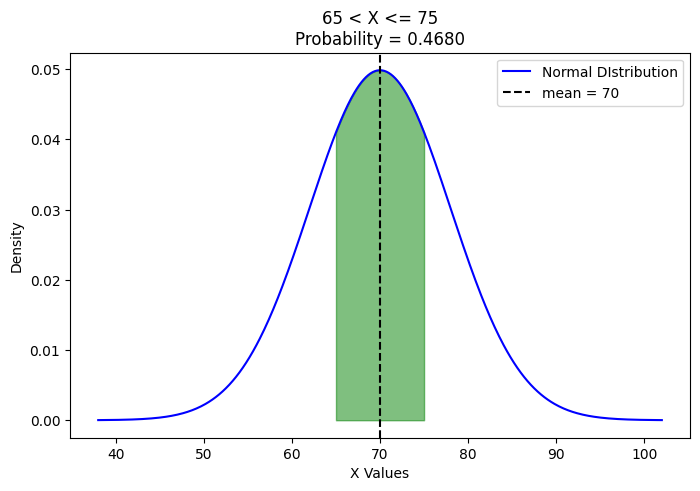

In [24]:
mu= 70
sigma=8
prob= normal_prob_analyser(mu, sigma, 65, 75,n=500)

Que 2. A machine fills milk packets with mean 1 liter and std dev 0.05.
What’s the probability that a randomly chosen packet has less than 0.95 liters?

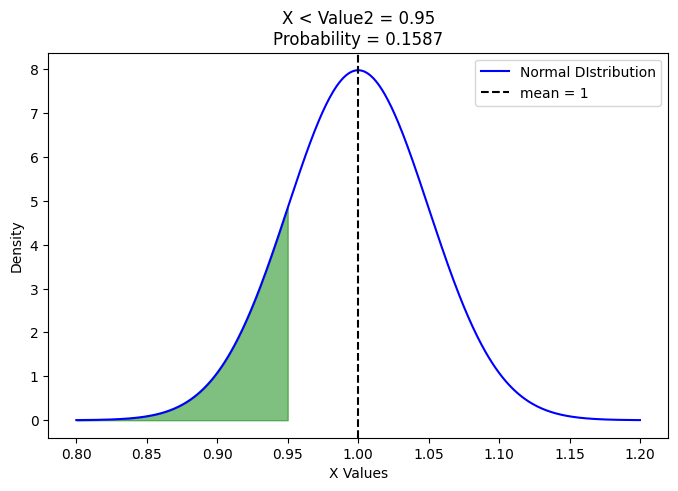

{'Case ': 'X < Value2 = 0.95',
 'Probability': np.float64(0.16),
 'Expected Count ': None}

In [27]:
mean=1
std_dev= 0.05
value2=0.95
result= normal_prob_analyser(mean, std_dev, value2=value2)
result

Que3 : Average human height in a region is 168 cm (σ = 7 cm). What fraction of population is taller than 180 cm?

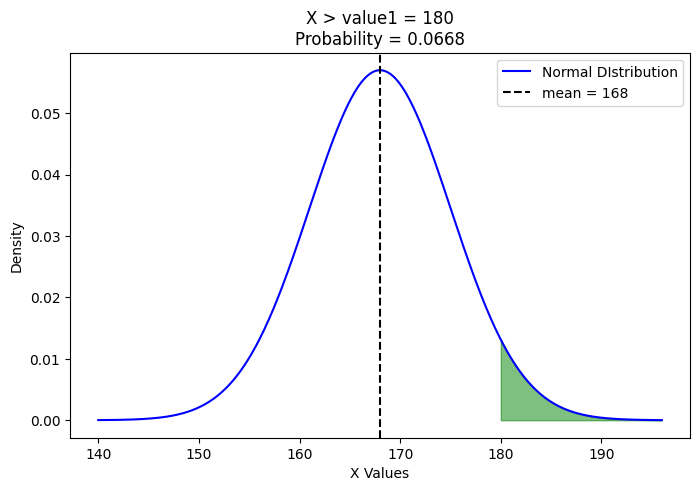

{'Case ': 'X > value1 = 180',
 'Probability': np.float64(0.07),
 'Expected Count ': None}

In [29]:
mean= 168
std_dev= 7
value1= 180
result= normal_prob_analyser(mean, std_dev, value1=value1)
result

Que4 . In an online store, customer purchase amounts follow N(₹1200, ₹300).Find the probability that a customer spends between ₹1000 and ₹1500.

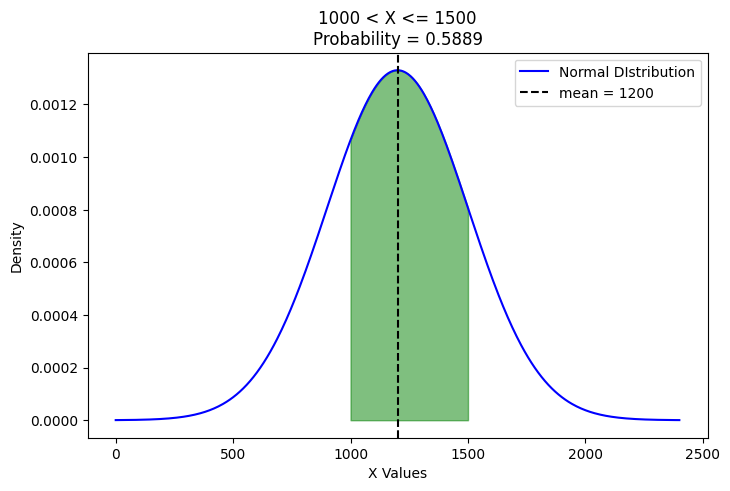

{'Case ': '1000 < X <= 1500',
 'Probability': np.float64(0.59),
 'Expected Count ': None}

In [30]:
mean=1200
std_dev=300
value1=1000
value2=1500
result= normal_prob_analyser(mean, std_dev, value1, value2)
result

Que5. SAT exam scores follow N(500, 100).If a university only admits students in the top 10%, what is the cutoff score?

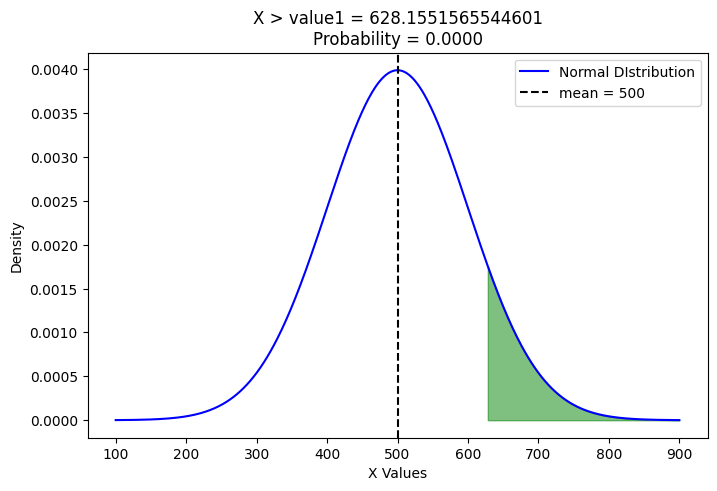

In [33]:
mean= 500
std_dev= 100
value=0.90 # 10% top percentile so 90% is lower than that
# first standardize it using z_score formula
z_score= norm.ppf(value)
#z_score #1.2815
cuttoff= mean + z_score * std_dev
cuttoff 
result= normal_prob_analyser(mean, std_dev, value1=cuttoff)

Que6. Daily sales of a product follow N(200, 40).
On a given day, you observe sales = 280.
Is this an outlier at 95% confidence?

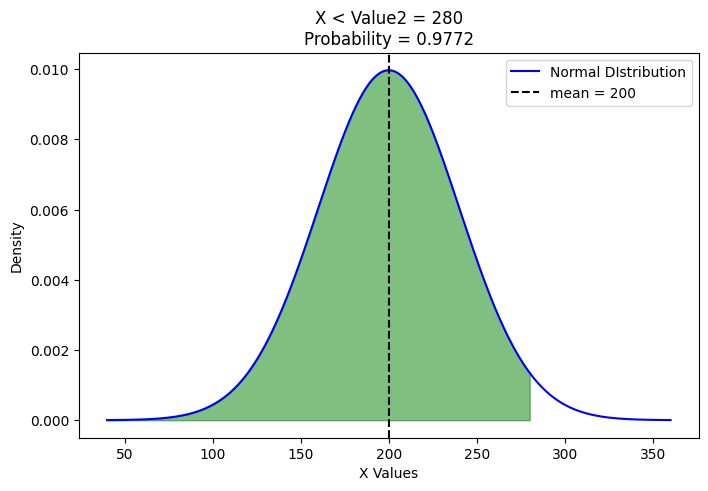

In [40]:

result= normal_prob_analyser(200, 40, value2=280)


Que7. A call center’s average handling time = 6 minutes (σ = 1.5).
Management wants to ensure that 95% of calls are below 9 minutes.
Is the current process acceptable?

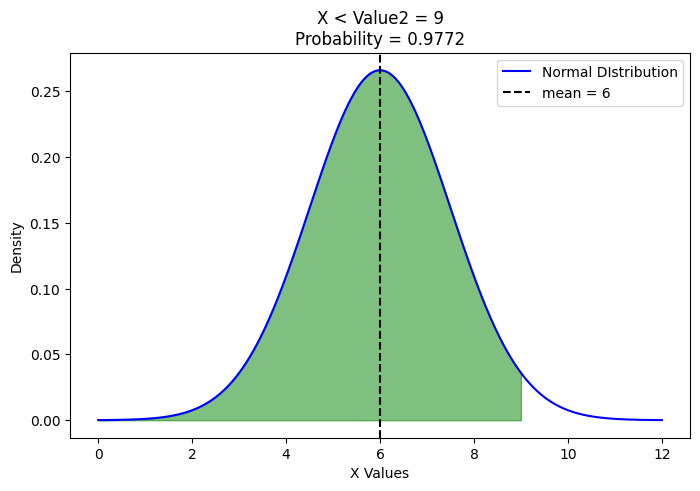

np.float64(0.98)

In [41]:
result= normal_prob_analyser(6,1.5, value2=9 )
result['Probability']

Here the prob is 98% which is exceeding the expected 95% prob

Que9. A hospital’s cholesterol readings follow N(190, 20).
For a patient with cholesterol = 230, find the percentile rank.

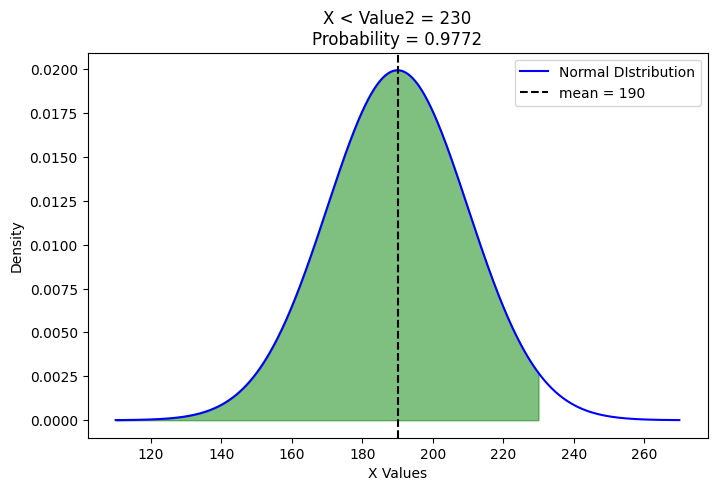

np.float64(0.98)

In [43]:
result= normal_prob_analyser(190, 20,value2=230)
result['Probability'] # 98%